GPU memory configuration and Library importing


In [2]:
# GPU Memory Configuration
from tensorflow.compat.v1 import ConfigProto, InteractiveSession

gpu_config = ConfigProto()
gpu_config.gpu_options.per_process_gpu_memory_fraction = 0.5
gpu_config.gpu_options.allow_growth = True
session = InteractiveSession(config=gpu_config)

# Imports
import gdown
import urllib.request
import zipfile
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from glob import glob
import os
import matplotlib.pyplot as plt


Loading Dataset


In [3]:
# Load the dataset

#
file_id = "1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA"
gdown.download(f"https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA", "cotton_disease_dataset.zip", quiet=False)




Downloading...
From (original): https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA
From (redirected): https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA&confirm=t&uuid=0bcb0d75-fc8a-4c1b-8bf8-3e719aa90d68
To: /content/cotton_disease_dataset.zip
100%|██████████| 162M/162M [00:03<00:00, 53.2MB/s]


'cotton_disease_dataset.zip'

In [4]:
with zipfile.ZipFile("cotton_disease_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction complete!")

Extraction complete!


 Define Paths and Image Size



In [5]:
# Image dimensions
IMAGE_SIZE = [224, 224]

# Data directories
TRAINING_DIR = '/content/dataset/data/train'
VALIDATION_DIR = '/content/dataset/data/val'

# Fetch number of output classes
class_labels = glob(os.path.join(TRAINING_DIR, '*'))
num_classes = len(class_labels)
print("Detected Classes:", [os.path.basename(cls) for cls in class_labels])


Detected Classes: ['diseased cotton leaf', 'fresh cotton plant', 'diseased cotton plant', 'fresh cotton leaf']


Load InceptionV3 Base Model

In [6]:
# Load InceptionV3 without top layers, with ImageNet weights
base_model = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Custom Layers on Top



In [7]:
# Add custom layers on top of the base model
custom_layers = Flatten()(base_model.output)
custom_layers = Dense(256, activation='relu')(custom_layers)
custom_layers = Dense(num_classes, activation='softmax')(custom_layers)

# Final model
disease_classifier = Model(inputs=base_model.input, outputs=custom_layers)
disease_classifier.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 34,911,268 (133.18 MB)

 Trainable params: 13,108,484 (50.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Data Augmentation and Generators

In [8]:
# Data augmentation
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   zoom_range=0.2,
                                   shear_range=0.
                                   )

val_datagen = ImageDataGenerator(rescale=1./255)

# Load images
train_set = train_datagen.flow_from_directory(TRAINING_DIR,
                                              target_size=IMAGE_SIZE,
                                              batch_size=32,
                                              class_mode='categorical')

val_set = val_datagen.flow_from_directory(VALIDATION_DIR,
                                          target_size=IMAGE_SIZE,
                                          batch_size=32,
                                          class_mode='categorical')


Found 1951 images belonging to 4 classes.
Found 324 images belonging to 4 classes.


Compile and Train Model

In [9]:
# Compile
disease_classifier.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])



# Train
history = disease_classifier.fit(train_set,
                                 validation_data=val_set,
                                 epochs=20,
                                 steps_per_epoch=len(train_set),
                                 validation_steps=len(val_set)
                                 )


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 333s 5s/step - accuracy: 0.4910 - loss: 16.2696 - val_accuracy: 0.8580 - val_loss: 0.4400
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 370s 6s/step - accuracy: 0.8782 - loss: 0.3751 - val_accuracy: 0.9290 - val_loss: 0.1993
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 329s 5s/step - accuracy: 0.9173 - loss: 0.2261 - val_accuracy: 0.9228 - val_loss: 0.1891
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 417s 6s/step - accuracy: 0.9227 - loss: 0.2207 - val_accuracy: 0.9352 - val_loss: 0.1815
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 328s 5s/step - accuracy: 0.9332 - loss: 0.1923 - val_accuracy: 0.9167 - val_loss: 0.2129
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 377s 5s/step - accuracy: 0.9436 - loss: 0.1633 - val_accuracy: 0.9506 - val_loss: 0.1351
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 381s 5s/step - accuracy: 0.9598 - loss: 0.1105 - val_accuracy: 0.9568 - val_loss: 0.1247
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 324s 5s/step - accuracy: 0.9570 - loss: 0.1343 - val_accuracy: 0.9352 - 

Visualize Training Performance

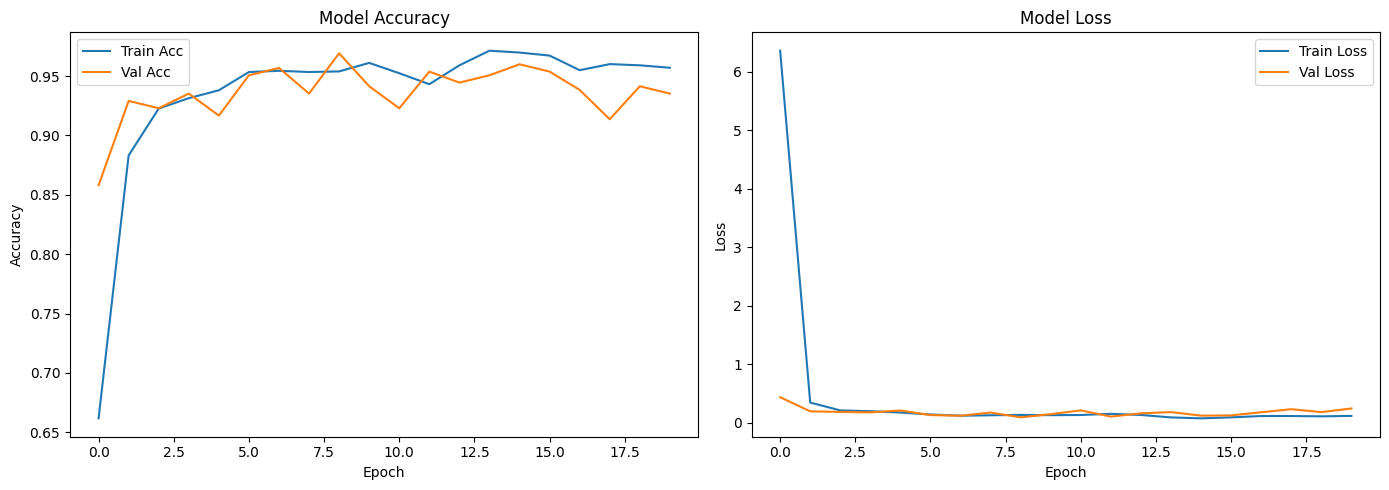

In [10]:
# Accuracy and loss plots
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Saving the trained model

In [12]:
disease_classifier.save('crop_disease_model.h5')  # if it's a Keras model
